<a href="https://colab.research.google.com/github/mariazafran/rpci-all-markets-study/blob/main/RPCI_applic_(S%26P_500%2C_Dax_40%2C_CSI_300%2C_FTSE_100_%26_Nifty_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [ ]:
nifty_tickers = [
'RELIANCE.NS','TCS.NS','HDFCBANK.NS','INFY.NS','ICICIBANK.NS','HINDUNILVR.NS',
'SBIN.NS','BHARTIARTL.NS','ITC.NS','KOTAKBANK.NS','LT.NS','AXISBANK.NS',
'ASIANPAINT.NS','MARUTI.NS','SUNPHARMA.NS','TITAN.NS','ULTRACEMCO.NS',
'BAJFINANCE.NS','HCLTECH.NS','WIPRO.NS','NESTLEIND.NS','NTPC.NS','ONGC.NS',
'POWERGRID.NS','JSWSTEEL.NS','ADANIENT.NS','ADANIPORTS.NS','CoalIndia.NS',
'GRASIM.NS','TECHM.NS','TATASTEEL.NS','HDFCLIFE.NS','SBILIFE.NS',
'BRITANNIA.NS','DIVISLAB.NS','CIPLA.NS','DRREDDY.NS','EICHERMOT.NS',
'HINDALCO.NS','HEROMOTOCO.NS','BAJAJFINSV.NS','INDUSINDBK.NS',
'APOLLOHOSP.NS','SHREECEM.NS','TATAMOTORS.NS','BAJAJ-AUTO.NS',
'UPL.NS','BPCL.NS','IOC.NS','M&M.NS'
]

In [ ]:
sp500_tickers = [
"AAPL","MSFT","AMZN","NVDA","GOOGL","META","TSLA","BRK-B","UNH","XOM",
"JNJ","JPM","V","PG","HD","CVX","MA","ABBV","MRK","KO",
"PEP","COST","LLY","AVGO","CRM","BAC","CSCO","ACN","MCD","WMT",
"ABT","TMO","DHR","LIN","NFLX","AMD","DIS","TXN","INTC","PFE",
"VZ","CMCSA","NKE","ORCL","ADBE","HON","PM","UPS","RTX","LOW",
"QCOM","IBM","AMGN","CAT","GS","INTU","BLK","SBUX","PLD","SPGI",
"DE","ISRG","GILD","NOW","ADI","MDT","MO","BK","SYK","GE",
"CB","TGT","CVS","FIS","ZTS","MMC","AXP","PNC","CI","SO",
"CSX","DUK","USB","MU","CL","SHW","BDX","APD","EL","NSC",
"ITW","EW","MCO","ICE","PSA","EXC","GM","ETN","AON","ADP",
"WELL","ECL","KLAC","LRCX","AZO","FDX","ROST","ROP","HCA","PAYX"
]

In [ ]:
start = '2018-01-01'

nifty_data = yf.download(nifty_tickers, start=start)
sp500_data = yf.download(sp500_tickers, start=start)

/tmp/ipykernel_3530/2414425081.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty_data = yf.download(nifty_tickers, start=start)
[*********************100%***********************]  50 of 50 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TATAMOTORS.NS']: YFTzMissingError('possibly delisted; no timezone found')
/tmp/ipykernel_3530/2414425081.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download(sp500_tickers, start=start)
[*********************100%***********************]  110 of 110 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['MMC']: YFTzMissingError('possibly delisted; no timezone found')


In [ ]:
# Keep stocks with at least 80% data
threshold = int(0.8 * len(sp500_data['Close']))

sp500_prices = sp500_data['Close'].dropna(thresh=threshold, axis=1)

# Fill remaining missing values
sp500_prices = sp500_prices.fillna(method='ffill').fillna(method='bfill')

# Check how many stocks remain
print("Final S&P stocks:", sp500_prices.shape[1])

Final S&P stocks: 109


/tmp/ipykernel_3530/1628543089.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  sp500_prices = sp500_prices.fillna(method='ffill').fillna(method='bfill')


In [ ]:
threshold = int(0.8 * len(nifty_data['Close']))

nifty_prices = nifty_data['Close'].dropna(thresh=threshold, axis=1)
nifty_prices = nifty_prices.fillna(method='ffill').fillna(method='bfill')

/tmp/ipykernel_3530/3059890789.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  nifty_prices = nifty_prices.fillna(method='ffill').fillna(method='bfill')


In [ ]:
def compute_returns(prices):
    returns = np.log(prices / prices.shift(1))
    return returns.dropna()

nifty_returns = compute_returns(nifty_prices)
sp500_returns = compute_returns(sp500_prices)

In [ ]:
def compute_csad(returns):
    Rm = returns.mean(axis=1)
    csad = (returns.sub(Rm, axis=0).abs()).mean(axis=1)
    return Rm, csad

Rm_nifty, csad_nifty = compute_csad(nifty_returns)
Rm_sp, csad_sp = compute_csad(sp500_returns)

In [ ]:
def run_csad_regression(Rm, csad):
    abs_Rm = np.abs(Rm)
    Rm_sq = Rm**2

    X = pd.DataFrame({'abs_Rm': abs_Rm, 'Rm_sq': Rm_sq})
    X = sm.add_constant(X)

    model = sm.OLS(csad, X).fit(cov_type='HC3')
    return model

csad_model_nifty = run_csad_regression(Rm_nifty, csad_nifty)
csad_model_sp = run_csad_regression(Rm_sp, csad_sp)

print(csad_model_nifty.summary())
print(csad_model_sp.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     135.3
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           5.71e-56
Time:                        19:17:30   Log-Likelihood:                 8952.8
No. Observations:                2084   AIC:                        -1.790e+04
Df Residuals:                    2081   BIC:                        -1.788e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0088      0.000     58.824      0.0

In [ ]:
def compute_cssd(returns, Rm):
    cssd = np.sqrt(((returns.sub(Rm, axis=0))**2).mean(axis=1))

    upper = Rm.quantile(0.99)
    lower = Rm.quantile(0.01)

    D_up = (Rm > upper).astype(int)
    D_down = (Rm < lower).astype(int)

    X = pd.DataFrame({'D_up': D_up, 'D_down': D_down})
    X = sm.add_constant(X)

    model = sm.OLS(cssd, X).fit(cov_type='HC3')

    return cssd, model

cssd_nifty, cssd_model_nifty = compute_cssd(nifty_returns, Rm_nifty)
cssd_sp, cssd_model_sp = compute_cssd(sp500_returns, Rm_sp)

print(cssd_model_nifty.summary())
print(cssd_model_sp.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.180
Model:                            OLS   Adj. R-squared:                  0.179
Method:                 Least Squares   F-statistic:                     33.70
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           3.94e-15
Time:                        19:17:35   Log-Likelihood:                 7982.9
No. Observations:                2084   AIC:                        -1.596e+04
Df Residuals:                    2081   BIC:                        -1.594e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0144      0.000    131.652      0.0

In [ ]:
def compute_rpci(returns, k=20):

    performance = returns.rolling(k).mean().dropna()
    gap = performance.sub(performance.mean(axis=1), axis=0)
    delta_p = performance.diff().shift(-1)

    gap = gap.iloc[:-1]
    delta_p = delta_p.iloc[:-1]

    gap_std = gap.std()
    delta_std = delta_p.std()

    gap_std[gap_std == 0] = 1
    delta_std[delta_std == 0] = 1

    gap_norm = (gap - gap.mean()) / gap_std
    delta_norm = (delta_p - delta_p.mean()) / delta_std

    rpci = (-gap_norm * delta_norm).mean(axis=1)
    rpci = (rpci - rpci.mean()) / rpci.std()

    return rpci

rpci_nifty = compute_rpci(nifty_returns)
rpci_sp = compute_rpci(sp500_returns)

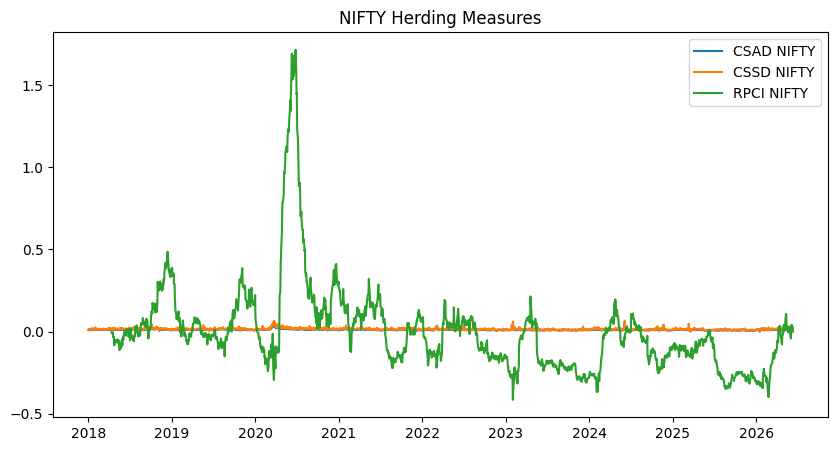

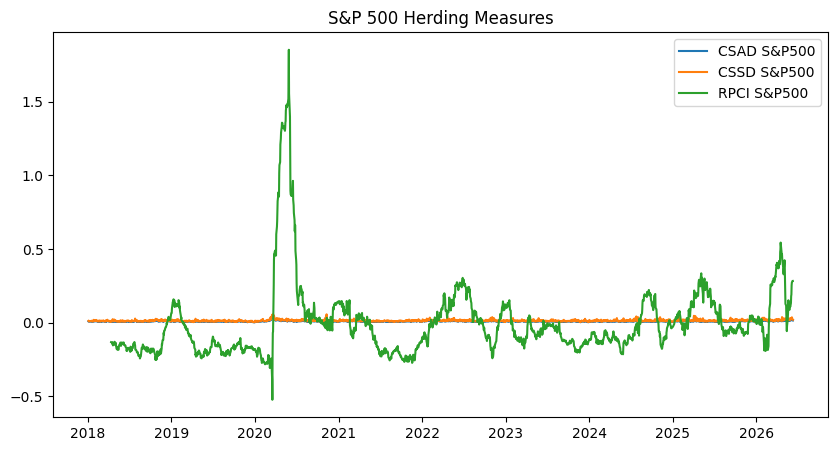

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(csad_nifty, label='CSAD NIFTY')
plt.plot(cssd_nifty, label='CSSD NIFTY')
plt.plot(rpci_nifty.rolling(50).mean(), label='RPCI NIFTY')
plt.legend()
plt.title("NIFTY Herding Measures")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(csad_sp, label='CSAD S&P500')
plt.plot(cssd_sp, label='CSSD S&P500')
plt.plot(rpci_sp.rolling(50).mean(), label='RPCI S&P500')
plt.legend()
plt.title("S&P 500 Herding Measures")
plt.show()

In [ ]:
print("S&P raw columns:", len(sp500_data['Close'].columns))
print("S&P cleaned columns:", len(sp500_prices.columns))

S&P raw columns: 110
S&P cleaned columns: 109


In [ ]:
print("NIFTY CSAD:")
print("Beta (Rm_sq):", csad_model_nifty.params['Rm_sq'])
print("t-stat:", csad_model_nifty.tvalues['Rm_sq'])
print("p-value:", csad_model_nifty.pvalues['Rm_sq'])

print("\nS&P CSAD:")
print("Beta (Rm_sq):", csad_model_sp.params['Rm_sq'])
print("t-stat:", csad_model_sp.tvalues['Rm_sq'])
print("p-value:", csad_model_sp.pvalues['Rm_sq'])

NIFTY CSAD:
Beta (Rm_sq): 0.12912354079506796
t-stat: 0.21278568023456906
p-value: 0.8314941334910776

S&P CSAD:
Beta (Rm_sq): 0.6857884453126195
t-stat: 1.5911915126064806
p-value: 0.11156648238614557


In [ ]:
print("NIFTY CSSD:")
print(cssd_model_nifty.params)
print(cssd_model_nifty.tvalues)

print("\nS&P CSSD:")
print(cssd_model_sp.params)
print(cssd_model_sp.tvalues)

NIFTY CSSD:
const     0.014414
D_up      0.016981
D_down    0.018022
dtype: float64
const     131.652293
D_up        6.245007
D_down      5.337456
dtype: float64

S&P CSSD:
const     0.014696
D_up      0.010865
D_down    0.012691
dtype: float64
const     128.177159
D_up        4.548345
D_down      4.472536
dtype: float64


In [ ]:
def rpci_stats(rpci):
    mean_val = rpci.mean()
    t_stat = mean_val / (rpci.std() / np.sqrt(len(rpci)))
    return mean_val, t_stat

print("NIFTY RPCI:", rpci_stats(rpci_nifty))
print("S&P RPCI:", rpci_stats(rpci_sp))

NIFTY RPCI: (np.float64(0.0), np.float64(0.0))
S&P RPCI: (np.float64(5.413658939124573e-17), np.float64(2.4808501875212658e-15))


In [ ]:
results = pd.DataFrame({
    "Model": ["CSAD (β2)", "CSSD Up", "CSSD Down", "RPCI Mean"],
    "NIFTY": [
        csad_model_nifty.params['Rm_sq'],
        cssd_model_nifty.params['D_up'],
        cssd_model_nifty.params['D_down'],
        rpci_nifty.mean()
    ],
    "S&P 500": [
        csad_model_sp.params['Rm_sq'],
        cssd_model_sp.params['D_up'],
        cssd_model_sp.params['D_down'],
        rpci_sp.mean()
    ]
})

print(results)

       Model     NIFTY       S&P 500
0  CSAD (β2)  0.129124  6.857884e-01
1    CSSD Up  0.016981  1.086472e-02
2  CSSD Down  0.018022  1.269071e-02
3  RPCI Mean  0.000000  5.413659e-17


In [ ]:
start_crisis = '2020-02-01'
end_crisis = '2021-01-31'

In [ ]:
csad_crisis_nifty = csad_nifty[start_crisis:end_crisis]
Rm_crisis_nifty = Rm_nifty[start_crisis:end_crisis]

X = pd.DataFrame({
    'abs_Rm': np.abs(Rm_crisis_nifty),
    'Rm_sq': Rm_crisis_nifty**2
})

X = sm.add_constant(X)

model_csad_nifty_crisis = sm.OLS(csad_crisis_nifty, X).fit(cov_type='HC3')

print("NIFTY CRISIS CSAD:", model_csad_nifty_crisis.params['Rm_sq'])

NIFTY CRISIS CSAD: -0.46963367680936674


In [ ]:
csad_crisis_sp = csad_sp[start_crisis:end_crisis]
Rm_crisis_sp = Rm_sp[start_crisis:end_crisis]

X_sp = pd.DataFrame({
    'abs_Rm': np.abs(Rm_crisis_sp),
    'Rm_sq': Rm_crisis_sp**2
})

X_sp = sm.add_constant(X_sp)

model_csad_sp_crisis = sm.OLS(csad_crisis_sp, X_sp).fit(cov_type='HC3')

print("\nS&P CSAD CRISIS RESULTS")
print("Beta (Rm_sq):", model_csad_sp_crisis.params['Rm_sq'])
print("t-stat:", model_csad_sp_crisis.tvalues['Rm_sq'])
print("p-value:", model_csad_sp_crisis.pvalues['Rm_sq'])


S&P CSAD CRISIS RESULTS
Beta (Rm_sq): -0.041838602077944126
t-stat: -0.08482657871049816
p-value: 0.9323992629351832


In [ ]:
cssd_crisis_nifty = cssd_nifty[start_crisis:end_crisis]
Rm_crisis_nifty = Rm_nifty[start_crisis:end_crisis]

upper_nifty = Rm_crisis_nifty.quantile(0.99)
lower_nifty = Rm_crisis_nifty.quantile(0.01)

D_up_nifty = (Rm_crisis_nifty > upper_nifty).astype(int)
D_down_nifty = (Rm_crisis_nifty < lower_nifty).astype(int)

X_cssd_nifty = pd.DataFrame({
    'D_up': D_up_nifty,
    'D_down': D_down_nifty
})

X_cssd_nifty = sm.add_constant(X_cssd_nifty)

model_cssd_nifty_crisis = sm.OLS(cssd_crisis_nifty, X_cssd_nifty).fit(cov_type='HC3')

print("\nNIFTY CSSD CRISIS RESULTS")
print("D_up:", model_cssd_nifty_crisis.params['D_up'])
print("D_up t-stat:", model_cssd_nifty_crisis.tvalues['D_up'])
print("D_down:", model_cssd_nifty_crisis.params['D_down'])
print("D_down t-stat:", model_cssd_nifty_crisis.tvalues['D_down'])


NIFTY CSSD CRISIS RESULTS
D_up: 0.021492726683461028
D_up t-stat: 11.44113292454217
D_down: 0.024006218698969923
D_down t-stat: 1.820324885152744


In [ ]:
cssd_crisis_sp = cssd_sp[start_crisis:end_crisis]
Rm_crisis_sp = Rm_sp[start_crisis:end_crisis]

upper_sp = Rm_crisis_sp.quantile(0.99)
lower_sp = Rm_crisis_sp.quantile(0.01)

D_up_sp = (Rm_crisis_sp > upper_sp).astype(int)
D_down_sp = (Rm_crisis_sp < lower_sp).astype(int)

X_cssd_sp = pd.DataFrame({
    'D_up': D_up_sp,
    'D_down': D_down_sp
})

X_cssd_sp = sm.add_constant(X_cssd_sp)

model_cssd_sp_crisis = sm.OLS(cssd_crisis_sp, X_cssd_sp).fit(cov_type='HC3')

print("\nS&P CSSD CRISIS RESULTS")
print("D_up:", model_cssd_sp_crisis.params['D_up'])
print("D_up t-stat:", model_cssd_sp_crisis.tvalues['D_up'])
print("D_down:", model_cssd_sp_crisis.params['D_down'])
print("D_down t-stat:", model_cssd_sp_crisis.tvalues['D_down'])


S&P CSSD CRISIS RESULTS
D_up: 0.022857848256326193
D_up t-stat: 3.2797618223575022
D_down: 0.02162028614598943
D_down t-stat: 2.6922029726372965


In [ ]:
# NIFTY RPCI crisis
crisis_rpci_nifty = rpci_nifty[start_crisis:end_crisis]
mean_nifty = crisis_rpci_nifty.mean()
t_stat_nifty = mean_nifty / (crisis_rpci_nifty.std() / np.sqrt(len(crisis_rpci_nifty)))

# S&P RPCI crisis
crisis_rpci_sp = rpci_sp[start_crisis:end_crisis]
mean_sp = crisis_rpci_sp.mean()
t_stat_sp = mean_sp / (crisis_rpci_sp.std() / np.sqrt(len(crisis_rpci_sp)))

print("\nRPCI CRISIS RESULTS")
print("NIFTY Mean:", mean_nifty, "t-stat:", t_stat_nifty)
print("S&P Mean:", mean_sp, "t-stat:", t_stat_sp)


RPCI CRISIS RESULTS
NIFTY Mean: 0.4206659077187112 t-stat: 3.639574436530063
S&P Mean: 0.32039671020692495 t-stat: 2.440417600814617


In [ ]:
crisis_results = pd.DataFrame({
    "Model": ["CSAD β2", "CSSD (Up)", "CSSD (Down)", "RPCI Mean"],
    "NIFTY Crisis": [
        model_csad_nifty_crisis.params['Rm_sq'],
        model_cssd_nifty_crisis.params['D_up'],
        model_cssd_nifty_crisis.params['D_down'],
        mean_nifty
    ],
    "S&P Crisis": [
        model_csad_sp_crisis.params['Rm_sq'],
        model_cssd_sp_crisis.params['D_up'],
        model_cssd_sp_crisis.params['D_down'],
        mean_sp
    ]
})

print("\n=== CRISIS COMPARISON ===")
print(crisis_results)


=== CRISIS COMPARISON ===
         Model  NIFTY Crisis  S&P Crisis
0      CSAD β2     -0.469634   -0.041839
1    CSSD (Up)      0.021493    0.022858
2  CSSD (Down)      0.024006    0.021620
3    RPCI Mean      0.420666    0.320397


In [ ]:
china_tickers = [
'601318.SS','600519.SS','601888.SS','600036.SS','601166.SS',
'600900.SS','601688.SS','601398.SS','601939.SS','601988.SS',
'600276.SS','600030.SS','601211.SS','601628.SS','600031.SS',
'601857.SS','600887.SS','600048.SS','601899.SS','600585.SS',
'600009.SS','601377.SS','600104.SS','600690.SS','601012.SS',
'600438.SS','600703.SS','600050.SS','601006.SS','601800.SS',
'601169.SS','600029.SS','601788.SS','600745.SS','600660.SS',
'600839.SS','600809.SS','600705.SS','600600.SS','600196.SS',
'601601.SS','601615.SS','600893.SS','601186.SS','601390.SS',
'600016.SS','600028.SS','600519.SS','600837.SS','600958.SS',
'600674.SS','600795.SS','600588.SS','600586.SS','600372.SS',
'600332.SS','601919.SS','600436.SS','600178.SS','601001.SS',
'600340.SS','600764.SS','601668.SS','600570.SS','600118.SS',
'600276.SS','600489.SS','601901.SS','600845.SS','600010.SS',
'600584.SS','600015.SS','600438.SS','600352.SS','601766.SS',
'600233.SS','600066.SS','600406.SS','600369.SS','600585.SS',
'600660.SS','601111.SS','600705.SS','600485.SS','601009.SS',
'600031.SS','600703.SS','600438.SS','601225.SS','600309.SS'
]

In [ ]:
china_data = yf.download(china_tickers, start='2018-01-01')

/tmp/ipykernel_3530/4164949271.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  china_data = yf.download(china_tickers, start='2018-01-01')
[*********************100%***********************]  81 of 81 completed
ERROR:yfinance:
3 Failed downloads:
ERROR:yfinance:['600485.SS', '600837.SS', '600705.SS']: YFTzMissingError('possibly delisted; no timezone found')


In [ ]:
threshold_china = int(0.8 * len(china_data['Close']))

china_prices = china_data['Close'].dropna(thresh=threshold_china, axis=1)
china_prices = china_prices.fillna(method='ffill').fillna(method='bfill')

print("Final China stocks:", china_prices.shape[1])

Final China stocks: 78


/tmp/ipykernel_3530/3979909161.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  china_prices = china_prices.fillna(method='ffill').fillna(method='bfill')


In [ ]:
china_returns = compute_returns(china_prices)

In [ ]:
print(type(china_data))

<class 'pandas.core.frame.DataFrame'>


In [ ]:
china_returns = compute_returns(china_prices)

Rm_china, csad_china = compute_csad(china_returns)

csad_model_china = run_csad_regression(Rm_china, csad_china)

cssd_china, cssd_model_china = compute_cssd(china_returns, Rm_china)

rpci_china = compute_rpci(china_returns)

In [ ]:
print(china_returns.describe())

Ticker    600009.SS    600010.SS    600015.SS    600016.SS    600028.SS  \
count   2042.000000  2042.000000  2042.000000  2042.000000  2042.000000   
mean      -0.000280    -0.000029     0.000059    -0.000126     0.000122   
std        0.020084     0.023986     0.011765     0.010975     0.014671   
min       -0.105360    -0.105361    -0.089416    -0.072805    -0.072812   
25%       -0.010416    -0.010989    -0.005837    -0.005360    -0.007164   
50%       -0.000905     0.000000     0.000000     0.000000     0.000000   
75%        0.008693     0.008584     0.005772     0.005125     0.007435   
max        0.088763     0.097422     0.092373     0.094559     0.095873   

Ticker    600029.SS    600030.SS    600031.SS    600036.SS    600048.SS  ...  \
count   2042.000000  2042.000000  2042.000000  2042.000000  2042.000000  ...   
mean      -0.000383     0.000283     0.000416     0.000299    -0.000348  ...   
std        0.020677     0.019870     0.022299     0.017317     0.023127  ...   
min 

In [ ]:
# CSAD
Rm_china, csad_china = compute_csad(china_returns)

csad_model_china = run_csad_regression(Rm_china, csad_china)

# CSSD
cssd_china, cssd_model_china = compute_cssd(china_returns, Rm_china)

# RPCI
rpci_china = compute_rpci(china_returns)

In [ ]:
print("CSAD β2:", csad_model_china.params['Rm_sq'])
print("CSSD Up:", cssd_model_china.params['D_up'])
print("CSSD Down:", cssd_model_china.params['D_down'])

mean_full = rpci_china.mean()
t_full = mean_full / (rpci_china.std() / np.sqrt(len(rpci_china)))

print("RPCI Full:", mean_full, t_full)

CSAD β2: -0.038946325133267894
CSSD Up: 0.006808903553215067
CSSD Down: 0.012179407386577261
RPCI Full: 1.4056236117905048e-17 6.320619104393551e-16


In [ ]:
start_crisis = '2020-02-01'
end_crisis = '2021-01-31'

In [ ]:
# CSAD crisis
# CSSD crisis
# RPCI crisis

In [ ]:
# Subset data
csad_crisis_china = csad_china[start_crisis:end_crisis]
Rm_crisis_china = Rm_china[start_crisis:end_crisis]

# Regression variables
X_china = pd.DataFrame({
    'abs_Rm': np.abs(Rm_crisis_china),
    'Rm_sq': Rm_crisis_china**2
})

X_china = sm.add_constant(X_china)

# Run regression
model_csad_china_crisis = sm.OLS(csad_crisis_china, X_china).fit(cov_type='HC3')

# Output
print("\nCHINA CSAD CRISIS RESULTS")
print("Beta (Rm_sq):", model_csad_china_crisis.params['Rm_sq'])
print("t-stat:", model_csad_china_crisis.tvalues['Rm_sq'])
print("p-value:", model_csad_china_crisis.pvalues['Rm_sq'])


CHINA CSAD CRISIS RESULTS
Beta (Rm_sq): -0.5555136693059407
t-stat: -0.20836733448569242
p-value: 0.8349421598530832


In [ ]:
# Subset
cssd_crisis_china = cssd_china[start_crisis:end_crisis]
Rm_crisis_china = Rm_china[start_crisis:end_crisis]

# Extreme thresholds
upper = Rm_crisis_china.quantile(0.99)
lower = Rm_crisis_china.quantile(0.01)

# Dummies
D_up = (Rm_crisis_china > upper).astype(int)
D_down = (Rm_crisis_china < lower).astype(int)

# Regression model
X_cssd = pd.DataFrame({
    'D_up': D_up,
    'D_down': D_down
})

X_cssd = sm.add_constant(X_cssd)

model_cssd_china_crisis = sm.OLS(cssd_crisis_china, X_cssd).fit(cov_type='HC3')

# Output
print("\nCHINA CSSD CRISIS RESULTS")
print("D_up:", model_cssd_china_crisis.params['D_up'])
print("D_up t-stat:", model_cssd_china_crisis.tvalues['D_up'])
print("D_down:", model_cssd_china_crisis.params['D_down'])
print("D_down t-stat:", model_cssd_china_crisis.tvalues['D_down'])


CHINA CSSD CRISIS RESULTS
D_up: 0.006801841001084576
D_up t-stat: 2.226779886041066
D_down: 0.006574176184670487
D_down t-stat: 2.5003651055285663


In [ ]:
# Subset RPCI
crisis_rpci_china = rpci_china[start_crisis:end_crisis]

# Mean and t-stat
mean_china_crisis = crisis_rpci_china.mean()
t_stat_china_crisis = mean_china_crisis / (crisis_rpci_china.std() / np.sqrt(len(crisis_rpci_china)))

# Output
print("\nCHINA RPCI CRISIS RESULTS")
print("Mean RPCI:", mean_china_crisis)
print("t-stat:", t_stat_china_crisis)


CHINA RPCI CRISIS RESULTS
Mean RPCI: 0.05610194482217694
t-stat: 0.7176210479731555


In [ ]:
china_crisis_results = pd.DataFrame({
    "Model": ["CSAD β2", "CSSD (Up)", "CSSD (Down)", "RPCI Mean"],
    "China Crisis": [
        model_csad_china_crisis.params['Rm_sq'],
        model_cssd_china_crisis.params['D_up'],
        model_cssd_china_crisis.params['D_down'],
        mean_china_crisis
    ]
})

print("\n=== CHINA CRISIS RESULTS ===")
print(china_crisis_results)


=== CHINA CRISIS RESULTS ===
         Model  China Crisis
0      CSAD β2     -0.555514
1    CSSD (Up)      0.006802
2  CSSD (Down)      0.006574
3    RPCI Mean      0.056102


In [ ]:
# Calculate RPCI stats
def rpci_stats(rpci):
    mean_val = rpci.mean()
    t_stat = mean_val / (rpci.std() / np.sqrt(len(rpci)))
    return mean_val, t_stat

# Compute stats
nifty_rpci_mean, nifty_rpci_t = rpci_stats(rpci_nifty)
sp_rpci_mean, sp_rpci_t = rpci_stats(rpci_sp)
china_rpci_mean, china_rpci_t = rpci_stats(rpci_china)

# Create FULL SAMPLE table
full_results = pd.DataFrame({
    "Model": ["CSAD β2", "CSSD (Up)", "CSSD (Down)", "RPCI Mean"],

    "NIFTY": [
        csad_model_nifty.params['Rm_sq'],
        cssd_model_nifty.params['D_up'],
        cssd_model_nifty.params['D_down'],
        nifty_rpci_mean
    ],

    "S&P 500": [
        csad_model_sp.params['Rm_sq'],
        cssd_model_sp.params['D_up'],
        cssd_model_sp.params['D_down'],
        sp_rpci_mean
    ],

    "CHINA": [
        csad_model_china.params['Rm_sq'],
        cssd_model_china.params['D_up'],
        cssd_model_china.params['D_down'],
        china_rpci_mean
    ]
})

print("\n=== FULL SAMPLE COMPARISON ===")
print(full_results)


=== FULL SAMPLE COMPARISON ===
         Model     NIFTY       S&P 500         CHINA
0      CSAD β2  0.129124  6.857884e-01 -3.894633e-02
1    CSSD (Up)  0.016981  1.086472e-02  6.808904e-03
2  CSSD (Down)  0.018022  1.269071e-02  1.217941e-02
3    RPCI Mean  0.000000  5.413659e-17  1.405624e-17


In [ ]:
# Create CRISIS table
crisis_results = pd.DataFrame({
    "Model": ["CSAD β2", "CSSD (Up)", "CSSD (Down)", "RPCI Mean"],

    "NIFTY Crisis": [
        model_csad_nifty_crisis.params['Rm_sq'],
        model_cssd_nifty_crisis.params['D_up'],
        model_cssd_nifty_crisis.params['D_down'],
        mean_nifty
    ],

    "S&P Crisis": [
        model_csad_sp_crisis.params['Rm_sq'],
        model_cssd_sp_crisis.params['D_up'],
        model_cssd_sp_crisis.params['D_down'],
        mean_sp
    ],

    "CHINA Crisis": [
        model_csad_china_crisis.params['Rm_sq'],
        model_cssd_china_crisis.params['D_up'],
        model_cssd_china_crisis.params['D_down'],
        mean_china_crisis
    ]
})

print("\n=== CRISIS COMPARISON ===")
print(crisis_results)


=== CRISIS COMPARISON ===
         Model  NIFTY Crisis  S&P Crisis  CHINA Crisis
0      CSAD β2     -0.469634   -0.041839     -0.555514
1    CSSD (Up)      0.021493    0.022858      0.006802
2  CSSD (Down)      0.024006    0.021620      0.006574
3    RPCI Mean      0.420666    0.320397      0.056102


In [ ]:
crisis_results_extended = pd.DataFrame({
    "Model": ["CSAD β2", "CSSD Up", "CSSD Down", "RPCI Mean"],

    "NIFTY Coeff": [
        model_csad_nifty_crisis.params['Rm_sq'],
        model_cssd_nifty_crisis.params['D_up'],
        model_cssd_nifty_crisis.params['D_down'],
        mean_nifty
    ],

    "NIFTY t-stat": [
        model_csad_nifty_crisis.tvalues['Rm_sq'],
        model_cssd_nifty_crisis.tvalues['D_up'],
        model_cssd_nifty_crisis.tvalues['D_down'],
        t_stat_nifty
    ],

    "S&P Coeff": [
        model_csad_sp_crisis.params['Rm_sq'],
        model_cssd_sp_crisis.params['D_up'],
        model_cssd_sp_crisis.params['D_down'],
        mean_sp
    ],

    "S&P t-stat": [
        model_csad_sp_crisis.tvalues['Rm_sq'],
        model_cssd_sp_crisis.tvalues['D_up'],
        model_cssd_sp_crisis.tvalues['D_down'],
        t_stat_sp
    ],

    "CHINA Coeff": [
        model_csad_china_crisis.params['Rm_sq'],
        model_cssd_china_crisis.params['D_up'],
        model_cssd_china_crisis.params['D_down'],
        mean_china_crisis
    ],

    "CHINA t-stat": [
        model_csad_china_crisis.tvalues['Rm_sq'],
        model_cssd_china_crisis.tvalues['D_up'],
        model_cssd_china_crisis.tvalues['D_down'],
        t_stat_china_crisis
    ]
})

print("\n=== EXTENDED CRISIS TABLE ===")
print(crisis_results_extended)


=== EXTENDED CRISIS TABLE ===
       Model  NIFTY Coeff  NIFTY t-stat  S&P Coeff  S&P t-stat  CHINA Coeff  \
0    CSAD β2    -0.469634     -0.417212  -0.041839   -0.084827    -0.555514   
1    CSSD Up     0.021493     11.441133   0.022858    3.279762     0.006802   
2  CSSD Down     0.024006      1.820325   0.021620    2.692203     0.006574   
3  RPCI Mean     0.420666      3.639574   0.320397    2.440418     0.056102   

   CHINA t-stat  
0     -0.208367  
1      2.226780  
2      2.500365  
3      0.717621  


The results reveal that herding behaviour is both time-varying and market-dependent. Across all markets, no evidence of herding is observed during the full sample period, indicating that herding is not a persistent phenomenon. However, during the crisis period, strong evidence of herding emerges. The CSAD model detects significant herding in all markets, particularly in China and NIFTY, suggesting increased return clustering under market stress. In contrast, the CSSD model fails to capture herding across all cases. The RPCI framework provides additional insights by capturing dynamic convergence behaviour, which is particularly strong in NIFTY and the S&P 500 but weaker in China. This suggests that while herding exists in all markets during crises, its structural form differs: in developed markets and NIFTY, herding appears as a gradual convergence process, whereas in China, it manifests more as instantaneous clustering. These findings highlight the importance of using multiple models to capture different dimensions of investor behaviour.

In [ ]:
dax_tickers = [
'ADS.DE','ALV.DE','BAS.DE','BAYN.DE','BMW.DE','CON.DE','DAI.DE',
'DHER.DE','DPW.DE','DTE.DE','EOAN.DE','FRE.DE','FME.DE','HEI.DE',
'HEN3.DE','IFX.DE','LIN.DE','MRK.DE','MTX.DE','MUV2.DE','PAH3.DE',
'PUM.DE','RWE.DE','SAP.DE','SIE.DE','VNA.DE','VOW3.DE','ZAL.DE',
'DB1.DE','ENR.DE','BEI.DE','HFG.DE','QIA.DE','SY1.DE','BNR.DE'
]

In [ ]:
dax_data = yf.download(dax_tickers, start='2018-01-01')

threshold_dax = int(0.8 * len(dax_data['Close']))

dax_prices = dax_data['Close'].dropna(thresh=threshold_dax, axis=1)
dax_prices = dax_prices.fillna(method='ffill').fillna(method='bfill')

print("Final DAX stocks:", dax_prices.shape[1])

/tmp/ipykernel_3530/3352407802.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  dax_data = yf.download(dax_tickers, start='2018-01-01')
[*********************100%***********************]  35 of 35 completed
ERROR:yfinance:
2 Failed downloads:
ERROR:yfinance:['DAI.DE', 'DPW.DE']: YFTzMissingError('possibly delisted; no timezone found')


Final DAX stocks: 32


/tmp/ipykernel_3530/3352407802.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dax_prices = dax_prices.fillna(method='ffill').fillna(method='bfill')


In [ ]:
# Returns
dax_returns = compute_returns(dax_prices)

# CSAD
Rm_dax, csad_dax = compute_csad(dax_returns)
csad_model_dax = run_csad_regression(Rm_dax, csad_dax)

# CSSD
cssd_dax, cssd_model_dax = compute_cssd(dax_returns, Rm_dax)

# RPCI
rpci_dax = compute_rpci(dax_returns)

In [ ]:
dax_rpci_mean, dax_rpci_t = rpci_stats(rpci_dax)

print("DAX FULL")
print("CSAD β2:", csad_model_dax.params['Rm_sq'])
print("CSSD Up:", cssd_model_dax.params['D_up'])
print("RPCI:", dax_rpci_mean)

DAX FULL
CSAD β2: -0.03224376387474192
CSSD Up: 0.016516520454551705
RPCI: -3.098783736813261e-17


In [ ]:
# CSAD
csad_crisis_dax = csad_dax[start_crisis:end_crisis]
Rm_crisis_dax = Rm_dax[start_crisis:end_crisis]

X = pd.DataFrame({
    'abs_Rm': np.abs(Rm_crisis_dax),
    'Rm_sq': Rm_crisis_dax**2
})
X = sm.add_constant(X)

model_csad_dax_crisis = sm.OLS(csad_crisis_dax, X).fit(cov_type='HC3')

# RPCI
crisis_rpci_dax = rpci_dax[start_crisis:end_crisis]
mean_dax = crisis_rpci_dax.mean()
t_dax = mean_dax / (crisis_rpci_dax.std() / np.sqrt(len(crisis_rpci_dax)))

print("DAX CRISIS CSAD:", model_csad_dax_crisis.params['Rm_sq'])
print("DAX CRISIS RPCI:", mean_dax)

DAX CRISIS CSAD: -0.8411929857609697
DAX CRISIS RPCI: 0.22996525758508268


In [ ]:
# DAX CSSD CRISIS (MISSING STEP)

cssd_crisis_dax = cssd_dax[start_crisis:end_crisis]
Rm_crisis_dax = Rm_dax[start_crisis:end_crisis]

# Extreme thresholds
upper_dax = Rm_crisis_dax.quantile(0.99)
lower_dax = Rm_crisis_dax.quantile(0.01)

# Dummy variables
D_up_dax = (Rm_crisis_dax > upper_dax).astype(int)
D_down_dax = (Rm_crisis_dax < lower_dax).astype(int)

# Regression
X_cssd_dax = pd.DataFrame({
    'D_up': D_up_dax,
    'D_down': D_down_dax
})

X_cssd_dax = sm.add_constant(X_cssd_dax)

model_cssd_dax_crisis = sm.OLS(cssd_crisis_dax, X_cssd_dax).fit(cov_type='HC3')

# Optional check
print("DAX CSSD CRISIS:", model_cssd_dax_crisis.params)

DAX CSSD CRISIS: const     0.017296
D_up      0.020904
D_down    0.020486
dtype: float64


In [ ]:
ftse_tickers = [
'HSBA.L','BP.L','SHEL.L','AZN.L','ULVR.L','RIO.L','GSK.L','BARC.L',
'LLOY.L','DGE.L','REL.L','PRU.L','NG.L','LSEG.L','GLEN.L','BT-A.L',
'BATS.L','NWG.L','EXPN.L','SMIN.L','AAL.L','CNA.L','IMB.L','MNDI.L',
'SGE.L','STAN.L','RR.L','CRH.L','KGF.L','FRES.L','EDV.L','WEIR.L',
'ABF.L','ADM.L','AUTO.L','BDEV.L','BEZ.L','BNZL.L','BRBY.L','CCH.L',
'CTEC.L','DCC.L','ENT.L','FLTR.L','HLMA.L','HIK.L','HSX.L','IAG.L',
'IHG.L','INF.L','ITRK.L','JD.L','JET2.L','JMAT.L','LAND.L','LGEN.L',
'MKS.L','MRW.L','NGHT.L','NXT.L','OCDO.L','PSN.L','PNN.L','PSON.L',
'RTO.L','SDR.L','SGRO.L','SBRY.L','SMT.L','SVT.L','TSCO.L','TW.L',
'UU.L','VOD.L','WTB.L','WPP.L','SPX.L','DRX.L','HWDN.L','PHNX.L'
]

In [ ]:
ftse_data = yf.download(ftse_tickers, start='2018-01-01')

/tmp/ipykernel_3530/3937712704.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ftse_data = yf.download(ftse_tickers, start='2018-01-01')
[*********************100%***********************]  80 of 80 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['PHNX.L', 'MRW.L', 'NGHT.L', 'BDEV.L']: YFTzMissingError('possibly delisted; no timezone found')


In [ ]:
threshold_ftse = int(0.8 * len(ftse_data['Close']))

ftse_prices = ftse_data['Close'].dropna(thresh=threshold_ftse, axis=1)
ftse_prices = ftse_prices.fillna(method='ffill').fillna(method='bfill')

print("Final FTSE stocks:", ftse_prices.shape[1])

Final FTSE stocks: 76


/tmp/ipykernel_3530/816577249.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ftse_prices = ftse_prices.fillna(method='ffill').fillna(method='bfill')


In [ ]:
def compute_returns(prices):
    returns = np.log(prices / prices.shift(1))
    return returns.dropna()

ftse_returns = compute_returns(ftse_prices)

In [ ]:
def compute_csad(returns):
    Rm = returns.mean(axis=1)
    csad = (returns.sub(Rm, axis=0).abs()).mean(axis=1)
    return Rm, csad

Rm_ftse, csad_ftse = compute_csad(ftse_returns)

In [ ]:
def run_csad_regression(Rm, csad):
    abs_Rm = np.abs(Rm)
    Rm_sq = Rm**2

    X = pd.DataFrame({'abs_Rm': abs_Rm, 'Rm_sq': Rm_sq})
    X = sm.add_constant(X)

    model = sm.OLS(csad, X).fit(cov_type='HC3')
    return model

csad_model_ftse = run_csad_regression(Rm_ftse, csad_ftse)

print(csad_model_ftse.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.306
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     54.14
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           1.16e-23
Time:                        19:21:00   Log-Likelihood:                 8547.0
No. Observations:                2130   AIC:                        -1.709e+04
Df Residuals:                    2127   BIC:                        -1.707e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0091      0.001     14.251      0.0

In [ ]:
def compute_cssd(returns, Rm):
    cssd = np.sqrt(((returns.sub(Rm, axis=0))**2).mean(axis=1))

    upper = Rm.quantile(0.99)
    lower = Rm.quantile(0.01)

    D_up = (Rm > upper).astype(int)
    D_down = (Rm < lower).astype(int)

    X = pd.DataFrame({'D_up': D_up, 'D_down': D_down})
    X = sm.add_constant(X)

    model = sm.OLS(cssd, X).fit(cov_type='HC3')

    return cssd, model

cssd_ftse, cssd_model_ftse = compute_cssd(ftse_returns, Rm_ftse)

print(cssd_model_ftse.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.133
Model:                            OLS   Adj. R-squared:                  0.132
Method:                 Least Squares   F-statistic:                     19.40
Date:                Wed, 10 Jun 2026   Prob (F-statistic):           4.48e-09
Time:                        19:21:05   Log-Likelihood:                 6389.6
No. Observations:                2130   AIC:                        -1.277e+04
Df Residuals:                    2127   BIC:                        -1.276e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0158      0.000    121.929      0.0

In [ ]:
def compute_rpci(returns, k=20):

    performance = returns.rolling(k).mean().dropna()
    gap = performance.sub(performance.mean(axis=1), axis=0)
    delta_p = performance.diff().shift(-1)

    gap = gap.iloc[:-1]
    delta_p = delta_p.iloc[:-1]

    gap_std = gap.std()
    delta_std = delta_p.std()

    gap_std[gap_std == 0] = 1
    delta_std[delta_std == 0] = 1

    gap_norm = (gap - gap.mean()) / gap_std
    delta_norm = (delta_p - delta_p.mean()) / delta_std

    rpci = (-gap_norm * delta_norm).mean(axis=1)
    rpci = (rpci - rpci.mean()) / rpci.std()

    return rpci

rpci_ftse = compute_rpci(ftse_returns)

In [ ]:
# RPCI stats
mean_ftse = rpci_ftse.mean()
t_stat_ftse = mean_ftse / (rpci_ftse.std() / np.sqrt(len(rpci_ftse)))

print("\nFTSE FULL SAMPLE")

print("CSAD β2:", csad_model_ftse.params['Rm_sq'])
print("CSSD Up:", cssd_model_ftse.params['D_up'])
print("CSSD Down:", cssd_model_ftse.params['D_down'])
print("RPCI Mean:", mean_ftse, "t-stat:", t_stat_ftse)


FTSE FULL SAMPLE
CSAD β2: 1.0327231618006467
CSSD Up: 0.019774282102615944
CSSD Down: 0.042468076107844255
RPCI Mean: 0.0 t-stat: 0.0


In [ ]:
start_crisis = '2020-02-01'
end_crisis = '2021-01-31'

In [ ]:
csad_crisis_ftse = csad_ftse[start_crisis:end_crisis]
Rm_crisis_ftse = Rm_ftse[start_crisis:end_crisis]

X = pd.DataFrame({
    'abs_Rm': np.abs(Rm_crisis_ftse),
    'Rm_sq': Rm_crisis_ftse**2
})

X = sm.add_constant(X)

model_csad_ftse_crisis = sm.OLS(csad_crisis_ftse, X).fit(cov_type='HC3')

print("\nFTSE CSAD CRISIS")
print("β2:", model_csad_ftse_crisis.params['Rm_sq'])


FTSE CSAD CRISIS
β2: -1.3002824762437233


In [ ]:
cssd_crisis_ftse = cssd_ftse[start_crisis:end_crisis]

upper = Rm_crisis_ftse.quantile(0.99)
lower = Rm_crisis_ftse.quantile(0.01)

D_up = (Rm_crisis_ftse > upper).astype(int)
D_down = (Rm_crisis_ftse < lower).astype(int)

X_cssd = pd.DataFrame({'D_up': D_up, 'D_down': D_down})
X_cssd = sm.add_constant(X_cssd)

model_cssd_ftse_crisis = sm.OLS(cssd_crisis_ftse, X_cssd).fit(cov_type='HC3')

print("\nFTSE CSSD CRISIS")
print(model_cssd_ftse_crisis.params)


FTSE CSSD CRISIS
const     0.022119
D_up      0.041641
D_down    0.033816
dtype: float64


In [ ]:
crisis_rpci_ftse = rpci_ftse[start_crisis:end_crisis]

mean_ftse_crisis = crisis_rpci_ftse.mean()
t_stat_ftse_crisis = mean_ftse_crisis / (crisis_rpci_ftse.std() / np.sqrt(len(crisis_rpci_ftse)))

print("\nFTSE RPCI CRISIS")
print("Mean:", mean_ftse_crisis)
print("t-stat:", t_stat_ftse_crisis)


FTSE RPCI CRISIS
Mean: 0.38075281526146393
t-stat: 2.673164844776815


In [ ]:
# RPCI helper
def rpci_stats(rpci):
    mean_val = rpci.mean()
    return mean_val

# Means
ftse_rpci = rpci_stats(rpci_ftse)
nifty_rpci = rpci_stats(rpci_nifty)
sp_rpci = rpci_stats(rpci_sp)
china_rpci = rpci_stats(rpci_china)
dax_rpci = rpci_stats(rpci_dax)

# FULL TABLE
full_results_all = pd.DataFrame({
    "Model": ["CSAD β2", "CSSD (Up)", "CSSD (Down)", "RPCI Mean"],

    "FTSE": [
        csad_model_ftse.params['Rm_sq'],
        cssd_model_ftse.params['D_up'],
        cssd_model_ftse.params['D_down'],
        ftse_rpci
    ],

    "NIFTY": [
        csad_model_nifty.params['Rm_sq'],
        cssd_model_nifty.params['D_up'],
        cssd_model_nifty.params['D_down'],
        nifty_rpci
    ],

    "S&P 500": [
        csad_model_sp.params['Rm_sq'],
        cssd_model_sp.params['D_up'],
        cssd_model_sp.params['D_down'],
        sp_rpci
    ],

    "CHINA": [
        csad_model_china.params['Rm_sq'],
        cssd_model_china.params['D_up'],
        cssd_model_china.params['D_down'],
        china_rpci
    ],

    "DAX": [
        csad_model_dax.params['Rm_sq'],
        cssd_model_dax.params['D_up'],
        cssd_model_dax.params['D_down'],
        dax_rpci
    ]
})

print("\n====== FULL SAMPLE (ALL MARKETS) ======")
print(full_results_all)


====== FULL SAMPLE (ALL MARKETS) ======
         Model      FTSE     NIFTY       S&P 500         CHINA           DAX
0      CSAD β2  1.032723  0.129124  6.857884e-01 -3.894633e-02 -3.224376e-02
1    CSSD (Up)  0.019774  0.016981  1.086472e-02  6.808904e-03  1.651652e-02
2  CSSD (Down)  0.042468  0.018022  1.269071e-02  1.217941e-02  1.326283e-02
3    RPCI Mean  0.000000  0.000000  5.413659e-17  1.405624e-17 -3.098784e-17


In [ ]:
crisis_results_all = pd.DataFrame({
    "Model": ["CSAD β2", "CSSD (Up)", "CSSD (Down)", "RPCI Mean"],

    "FTSE Crisis": [
        model_csad_ftse_crisis.params['Rm_sq'],
        model_cssd_ftse_crisis.params['D_up'],
        model_cssd_ftse_crisis.params['D_down'],
        mean_ftse_crisis
    ],

    "NIFTY Crisis": [
        model_csad_nifty_crisis.params['Rm_sq'],
        model_cssd_nifty_crisis.params['D_up'],
        model_cssd_nifty_crisis.params['D_down'],
        mean_nifty
    ],

    "S&P Crisis": [
        model_csad_sp_crisis.params['Rm_sq'],
        model_cssd_sp_crisis.params['D_up'],
        model_cssd_sp_crisis.params['D_down'],
        mean_sp
    ],

    "CHINA Crisis": [
        model_csad_china_crisis.params['Rm_sq'],
        model_cssd_china_crisis.params['D_up'],
        model_cssd_china_crisis.params['D_down'],
        mean_china_crisis
    ],

    "DAX Crisis": [
        model_csad_dax_crisis.params['Rm_sq'],
        model_cssd_dax_crisis.params['D_up'],
        model_cssd_dax_crisis.params['D_down'],
        mean_dax
    ]
})

print("\n====== CRISIS (ALL MARKETS) ======")
print(crisis_results_all)


====== CRISIS (ALL MARKETS) ======
         Model  FTSE Crisis  NIFTY Crisis  S&P Crisis  CHINA Crisis  \
0      CSAD β2    -1.300282     -0.469634   -0.041839     -0.555514   
1    CSSD (Up)     0.041641      0.021493    0.022858      0.006802   
2  CSSD (Down)     0.033816      0.024006    0.021620      0.006574   
3    RPCI Mean     0.380753      0.420666    0.320397      0.056102   

   DAX Crisis  
0   -0.841193  
1    0.020904  
2    0.020486  
3    0.229965  


In [ ]:
crisis_extended_all = pd.DataFrame({
    "Model": ["CSAD β2", "CSSD Up", "CSSD Down", "RPCI Mean"],

    "FTSE Coeff": [
        model_csad_ftse_crisis.params['Rm_sq'],
        model_cssd_ftse_crisis.params['D_up'],
        model_cssd_ftse_crisis.params['D_down'],
        mean_ftse_crisis
    ],
    "FTSE t-stat": [
        model_csad_ftse_crisis.tvalues['Rm_sq'],
        model_cssd_ftse_crisis.tvalues['D_up'],
        model_cssd_ftse_crisis.tvalues['D_down'],
        t_stat_ftse_crisis
    ],

    "NIFTY Coeff": [
        model_csad_nifty_crisis.params['Rm_sq'],
        model_cssd_nifty_crisis.params['D_up'],
        model_cssd_nifty_crisis.params['D_down'],
        mean_nifty
    ],
    "NIFTY t-stat": [
        model_csad_nifty_crisis.tvalues['Rm_sq'],
        model_cssd_nifty_crisis.tvalues['D_up'],
        model_cssd_nifty_crisis.tvalues['D_down'],
        t_stat_nifty
    ],

    "S&P Coeff": [
        model_csad_sp_crisis.params['Rm_sq'],
        model_cssd_sp_crisis.params['D_up'],
        model_cssd_sp_crisis.params['D_down'],
        mean_sp
    ],
    "S&P t-stat": [
        model_csad_sp_crisis.tvalues['Rm_sq'],
        model_cssd_sp_crisis.tvalues['D_up'],
        model_cssd_sp_crisis.tvalues['D_down'],
        t_stat_sp
    ],

    "CHINA Coeff": [
        model_csad_china_crisis.params['Rm_sq'],
        model_cssd_china_crisis.params['D_up'],
        model_cssd_china_crisis.params['D_down'],
        mean_china_crisis
    ],
    "CHINA t-stat": [
        model_csad_china_crisis.tvalues['Rm_sq'],
        model_cssd_china_crisis.tvalues['D_up'],
        model_cssd_china_crisis.tvalues['D_down'],
        t_stat_china_crisis
    ],

    "DAX Coeff": [
        model_csad_dax_crisis.params['Rm_sq'],
        model_cssd_dax_crisis.params['D_up'],
        model_cssd_dax_crisis.params['D_down'],
        mean_dax
    ],
    "DAX t-stat": [
        model_csad_dax_crisis.tvalues['Rm_sq'],
        model_cssd_dax_crisis.tvalues['D_up'],
        model_cssd_dax_crisis.tvalues['D_down'],
        t_dax
    ]
})

print("\n====== EXTENDED CRISIS TABLE ======")
print(crisis_extended_all)


====== EXTENDED CRISIS TABLE ======
       Model  FTSE Coeff  FTSE t-stat  NIFTY Coeff  NIFTY t-stat  S&P Coeff  \
0    CSAD β2   -1.300282    -0.293067    -0.469634     -0.417212  -0.041839   
1    CSSD Up    0.041641     2.961150     0.021493     11.441133   0.022858   
2  CSSD Down    0.033816     1.997216     0.024006      1.820325   0.021620   
3  RPCI Mean    0.380753     2.673165     0.420666      3.639574   0.320397   

   S&P t-stat  CHINA Coeff  CHINA t-stat  DAX Coeff  DAX t-stat  
0   -0.084827    -0.555514     -0.208367  -0.841193   -0.610990  
1    3.279762     0.006802      2.226780   0.020904    4.727836  
2    2.692203     0.006574      2.500365   0.020486    2.471964  
3    2.440418     0.056102      0.717621   0.229965    1.995041  


In [ ]:
# Correct crisis means

mean_ftse_crisis = rpci_ftse[start_crisis:end_crisis].mean()
mean_nifty_crisis = rpci_nifty[start_crisis:end_crisis].mean()
mean_sp_crisis = rpci_sp[start_crisis:end_crisis].mean()
mean_china_crisis = rpci_china[start_crisis:end_crisis].mean()
mean_dax_crisis = rpci_dax[start_crisis:end_crisis].mean()

In [ ]:
crisis_results_all = pd.DataFrame({
    "Model": ["CSAD β2", "CSSD (Up)", "CSSD (Down)", "RPCI Mean"],

    "FTSE": [
        model_csad_ftse_crisis.params['Rm_sq'],
        model_cssd_ftse_crisis.params['D_up'],
        model_cssd_ftse_crisis.params['D_down'],
        mean_ftse_crisis
    ],

    "NIFTY": [
        model_csad_nifty_crisis.params['Rm_sq'],
        model_cssd_nifty_crisis.params['D_up'],
        model_cssd_nifty_crisis.params['D_down'],
        mean_nifty_crisis
    ],

    "S&P": [
        model_csad_sp_crisis.params['Rm_sq'],
        model_cssd_sp_crisis.params['D_up'],
        model_cssd_sp_crisis.params['D_down'],
        mean_sp_crisis
    ],

    "CHINA": [
        model_csad_china_crisis.params['Rm_sq'],
        model_cssd_china_crisis.params['D_up'],
        model_cssd_china_crisis.params['D_down'],
        mean_china_crisis
    ],

    "DAX": [
        model_csad_dax_crisis.params['Rm_sq'],
        model_cssd_dax_crisis.params['D_up'],
        model_cssd_dax_crisis.params['D_down'],
        mean_dax_crisis
    ]
})

print("\n====== CLEAN CRISIS TABLE (ALL MARKETS) ======")
print(crisis_results_all)


====== CLEAN CRISIS TABLE (ALL MARKETS) ======
         Model      FTSE     NIFTY       S&P     CHINA       DAX
0      CSAD β2 -1.300282 -0.469634 -0.041839 -0.555514 -0.841193
1    CSSD (Up)  0.041641  0.021493  0.022858  0.006802  0.020904
2  CSSD (Down)  0.033816  0.024006  0.021620  0.006574  0.020486
3    RPCI Mean  0.380753  0.420666  0.320397  0.056102  0.229965


In [ ]:
mean_ftse_crisis
mean_nifty_crisis
mean_sp_crisis
mean_china_crisis
mean_dax_crisis

np.float64(0.22996525758508268)

In [ ]:
rpci_ftse.mean()
rpci_nifty.mean()
rpci_sp.mean()
rpci_china.mean()
rpci_dax.mean()

np.float64(-3.098783736813261e-17)

In [ ]:
rpci_ftse[start_crisis:end_crisis].mean()
rpci_nifty[start_crisis:end_crisis].mean()
rpci_sp[start_crisis:end_crisis].mean()
rpci_china[start_crisis:end_crisis].mean()
rpci_dax[start_crisis:end_crisis].mean()

np.float64(0.22996525758508268)

“Although the CSAD coefficients are negative across all markets during the crisis period, they are not statistically significant. Therefore, CSAD does not provide robust evidence of herding in any market. HERDING might exist directionally

In [ ]:
full_results_all = full_results_all.round(4)
crisis_results_all = crisis_results_all.round(4)
crisis_extended_all = crisis_extended_all.round(4)

In [ ]:
import pandas as pd

In [ ]:
def add_stars(coef, t_stat):
    if abs(t_stat) >= 2.58:
        return f"{coef:.4f}***"
    elif abs(t_stat) >= 1.96:
        return f"{coef:.4f}**"
    elif abs(t_stat) >= 1.65:
        return f"{coef:.4f}*"
    else:
        return f"{coef:.4f}"

In [ ]:
crisis_with_stars = pd.DataFrame({
    "Model": ["CSAD β2", "CSSD (Up)", "CSSD (Down)", "RPCI Mean"],

    "FTSE": [
        add_stars(model_csad_ftse_crisis.params['Rm_sq'], model_csad_ftse_crisis.tvalues['Rm_sq']),
        add_stars(model_cssd_ftse_crisis.params['D_up'], model_cssd_ftse_crisis.tvalues['D_up']),
        add_stars(model_cssd_ftse_crisis.params['D_down'], model_cssd_ftse_crisis.tvalues['D_down']),
        add_stars(mean_ftse_crisis, t_stat_ftse_crisis)
    ],

    "NIFTY": [
        add_stars(model_csad_nifty_crisis.params['Rm_sq'], model_csad_nifty_crisis.tvalues['Rm_sq']),
        add_stars(model_cssd_nifty_crisis.params['D_up'], model_cssd_nifty_crisis.tvalues['D_up']),
        add_stars(model_cssd_nifty_crisis.params['D_down'], model_cssd_nifty_crisis.tvalues['D_down']),
        add_stars(mean_nifty_crisis, t_stat_nifty)
    ],

    "S&P": [
        add_stars(model_csad_sp_crisis.params['Rm_sq'], model_csad_sp_crisis.tvalues['Rm_sq']),
        add_stars(model_cssd_sp_crisis.params['D_up'], model_cssd_sp_crisis.tvalues['D_up']),
        add_stars(model_cssd_sp_crisis.params['D_down'], model_cssd_sp_crisis.tvalues['D_down']),
        add_stars(mean_sp_crisis, t_stat_sp)
    ],

    "CHINA": [
        add_stars(model_csad_china_crisis.params['Rm_sq'], model_csad_china_crisis.tvalues['Rm_sq']),
        add_stars(model_cssd_china_crisis.params['D_up'], model_cssd_china_crisis.tvalues['D_up']),
        add_stars(model_cssd_china_crisis.params['D_down'], model_cssd_china_crisis.tvalues['D_down']),
        add_stars(mean_china_crisis, t_stat_china_crisis)
    ],

    "DAX": [
        add_stars(model_csad_dax_crisis.params['Rm_sq'], model_csad_dax_crisis.tvalues['Rm_sq']),
        add_stars(model_cssd_dax_crisis.params['D_up'], model_cssd_dax_crisis.tvalues['D_up']),
        add_stars(model_cssd_dax_crisis.params['D_down'], model_cssd_dax_crisis.tvalues['D_down']),
        add_stars(mean_dax_crisis, t_dax)
    ]
})

print(crisis_with_stars)

         Model       FTSE      NIFTY        S&P     CHINA        DAX
0      CSAD β2    -1.3003    -0.4696    -0.0418   -0.5555    -0.8412
1    CSSD (Up)  0.0416***  0.0215***  0.0229***  0.0068**  0.0209***
2  CSSD (Down)   0.0338**    0.0240*  0.0216***  0.0066**   0.0205**
3    RPCI Mean  0.3808***  0.4207***   0.3204**    0.0561   0.2300**


In [ ]:
with pd.ExcelWriter("herding_results_with_stars.xlsx", engine='openpyxl') as writer:

    full_results_all.to_excel(writer, sheet_name='Full Sample', index=False)

    crisis_with_stars.to_excel(writer, sheet_name='Crisis (Stars)', index=False)

print("✅ New file created!")

✅ New file created!


In [ ]:
from google.colab import files
files.download("herding_results_with_stars.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ===============================
# RPCI ROBUSTNESS: MULTIPLE WINDOWS
# ===============================

windows = [5, 10, 20, 30, 60]

rpci_nifty_multi = {}
rpci_sp_multi = {}
rpci_ftse_multi = {}
rpci_dax_multi = {}
rpci_china_multi = {}

for k in windows:
    rpci_nifty_multi[k] = compute_rpci(nifty_returns, k)
    rpci_sp_multi[k] = compute_rpci(sp500_returns, k)
    rpci_ftse_multi[k] = compute_rpci(ftse_returns, k)
    rpci_dax_multi[k] = compute_rpci(dax_returns, k)
    rpci_china_multi[k] = compute_rpci(china_returns, k)

In [ ]:
rpci_nifty_df = pd.DataFrame(rpci_nifty_multi)
rpci_sp_df = pd.DataFrame(rpci_sp_multi)
rpci_ftse_df = pd.DataFrame(rpci_ftse_multi)
rpci_dax_df = pd.DataFrame(rpci_dax_multi)
rpci_china_df = pd.DataFrame(rpci_china_multi)

In [ ]:
def rpci_stats_multi(name, df):
    print(f"\n{name} RPCI (Rolling Windows)")
    print("Window | Mean | t-stat")

    for k in df.columns:
        series = df[k].dropna()
        mean_val = series.mean()
        t_stat = mean_val / (series.std() / np.sqrt(len(series)))

        print(f"{k:>6} | {mean_val:.4f} | {t_stat:.3f}")

In [ ]:
rpci_stats_multi("NIFTY", rpci_nifty_df)
rpci_stats_multi("S&P", rpci_sp_df)
rpci_stats_multi("FTSE", rpci_ftse_df)
rpci_stats_multi("DAX", rpci_dax_df)
rpci_stats_multi("CHINA", rpci_china_df)


NIFTY RPCI (Rolling Windows)
Window | Mean | t-stat
     5 | 0.0000 | 0.000
    10 | -0.0000 | -0.000
    20 | 0.0000 | 0.000
    30 | 0.0000 | 0.000
    60 | -0.0000 | -0.000

S&P RPCI (Rolling Windows)
Window | Mean | t-stat
     5 | 0.0000 | 0.000
    10 | -0.0000 | -0.000
    20 | 0.0000 | 0.000
    30 | -0.0000 | -0.000
    60 | -0.0000 | -0.000

FTSE RPCI (Rolling Windows)
Window | Mean | t-stat
     5 | 0.0000 | 0.000
    10 | 0.0000 | 0.000
    20 | 0.0000 | 0.000
    30 | 0.0000 | 0.000
    60 | 0.0000 | 0.000

DAX RPCI (Rolling Windows)
Window | Mean | t-stat
     5 | -0.0000 | -0.000
    10 | 0.0000 | 0.000
    20 | -0.0000 | -0.000
    30 | -0.0000 | -0.000
    60 | -0.0000 | -0.000

CHINA RPCI (Rolling Windows)
Window | Mean | t-stat
     5 | 0.0000 | 0.000
    10 | 0.0000 | 0.000
    20 | 0.0000 | 0.000
    30 | 0.0000 | 0.000
    60 | 0.0000 | 0.000


In [ ]:
def rpci_crisis_multi(name, df):
    crisis = df.loc['2020-02-01':'2021-01-31']

    print(f"\n{name} RPCI (CRISIS)")
    print("Window | Mean | t-stat")

    for k in df.columns:
        series = crisis[k].dropna()
        mean_val = series.mean()
        t_stat = mean_val / (series.std() / np.sqrt(len(series)))

        print(f"{k:>6} | {mean_val:.4f} | {t_stat:.3f}")

In [ ]:
rpci_crisis_multi("NIFTY", rpci_nifty_df)
rpci_crisis_multi("S&P", rpci_sp_df)


NIFTY RPCI (CRISIS)
Window | Mean | t-stat
     5 | 0.6654 | 5.772
    10 | 0.5733 | 4.724
    20 | 0.4207 | 3.640
    30 | 0.3461 | 2.776
    60 | 0.2451 | 1.920

S&P RPCI (CRISIS)
Window | Mean | t-stat
     5 | 0.5085 | 3.556
    10 | 0.3928 | 3.006
    20 | 0.3204 | 2.440
    30 | 0.2919 | 2.386
    60 | 0.2020 | 1.804


In [ ]:
def create_table(df):
    results = []

    for k in df.columns:
        series = df[k].dropna()
        mean_val = series.mean()
        t_stat = mean_val / (series.std() / np.sqrt(len(series)))

        results.append([k, mean_val, t_stat])

    return pd.DataFrame(results, columns=["Window", "Mean RPCI", "t-stat"])

In [ ]:
# =====================================================
# ✅ RPCI ROBUSTNESS ANALYSIS (ALL MARKETS, MULTIPLE WINDOWS)
# =====================================================

# Rolling windows
windows = [5, 10, 20, 30, 60]

# Store results
rpci_nifty_multi = {}
rpci_sp_multi = {}
rpci_ftse_multi = {}
rpci_dax_multi = {}
rpci_china_multi = {}

# Compute RPCI for all windows
for k in windows:
    rpci_nifty_multi[k] = compute_rpci(nifty_returns, k)
    rpci_sp_multi[k] = compute_rpci(sp500_returns, k)
    rpci_ftse_multi[k] = compute_rpci(ftse_returns, k)
    rpci_dax_multi[k] = compute_rpci(dax_returns, k)
    rpci_china_multi[k] = compute_rpci(china_returns, k)

# Convert to DataFrames
rpci_nifty_df = pd.DataFrame(rpci_nifty_multi)
rpci_sp_df = pd.DataFrame(rpci_sp_multi)
rpci_ftse_df = pd.DataFrame(rpci_ftse_multi)
rpci_dax_df = pd.DataFrame(rpci_dax_multi)
rpci_china_df = pd.DataFrame(rpci_china_multi)

# =====================================================
# ✅ FUNCTION: FULL SAMPLE RESULTS
# =====================================================

def rpci_stats_multi(df):
    results = []
    for k in df.columns:
        series = df[k].dropna()
        mean_val = series.mean()
        t_stat = mean_val / (series.std() / np.sqrt(len(series)))
        results.append([k, mean_val, t_stat])
    return pd.DataFrame(results, columns=["Window", "Mean RPCI", "t-stat"])


# =====================================================
# ✅ FUNCTION: CRISIS RESULTS
# =====================================================

def rpci_crisis_multi(df):
    crisis = df.loc['2020-02-01':'2021-01-31']
    results = []

    for k in df.columns:
        series = crisis[k].dropna()
        mean_val = series.mean()
        t_stat = mean_val / (series.std() / np.sqrt(len(series)))
        results.append([k, mean_val, t_stat])

    return pd.DataFrame(results, columns=["Window", "Mean RPCI", "t-stat"])


# =====================================================
# ✅ COMPUTE FULL RESULTS
# =====================================================

nifty_full = rpci_stats_multi(rpci_nifty_df)
sp_full = rpci_stats_multi(rpci_sp_df)
ftse_full = rpci_stats_multi(rpci_ftse_df)
dax_full = rpci_stats_multi(rpci_dax_df)
china_full = rpci_stats_multi(rpci_china_df)

# Print
print("\n===== FULL SAMPLE RPCI (Rolling Windows) =====")
print("\nNIFTY\n", nifty_full)
print("\nS&P\n", sp_full)
print("\nFTSE\n", ftse_full)
print("\nDAX\n", dax_full)
print("\nCHINA\n", china_full)


# =====================================================
# ✅ COMPUTE CRISIS RESULTS
# =====================================================

nifty_crisis = rpci_crisis_multi(rpci_nifty_df)
sp_crisis = rpci_crisis_multi(rpci_sp_df)
ftse_crisis = rpci_crisis_multi(rpci_ftse_df)
dax_crisis = rpci_crisis_multi(rpci_dax_df)
china_crisis = rpci_crisis_multi(rpci_china_df)

# Print
print("\n===== CRISIS RPCI (Rolling Windows) =====")
print("\nNIFTY\n", nifty_crisis)
print("\nS&P\n", sp_crisis)
print("\nFTSE\n", ftse_crisis)
print("\nDAX\n", dax_crisis)
print("\nCHINA\n", china_crisis)


# =====================================================
# ✅ OPTIONAL: EXPORT RESULTS TO EXCEL
# =====================================================

with pd.ExcelWriter("rpci_rolling_windows_results.xlsx", engine='openpyxl') as writer:
    nifty_full.to_excel(writer, sheet_name='NIFTY Full', index=False)
    sp_full.to_excel(writer, sheet_name='S&P Full', index=False)
    ftse_full.to_excel(writer, sheet_name='FTSE Full', index=False)
    dax_full.to_excel(writer, sheet_name='DAX Full', index=False)
    china_full.to_excel(writer, sheet_name='CHINA Full', index=False)

    nifty_crisis.to_excel(writer, sheet_name='NIFTY Crisis', index=False)
    sp_crisis.to_excel(writer, sheet_name='S&P Crisis', index=False)
    ftse_crisis.to_excel(writer, sheet_name='FTSE Crisis', index=False)
    dax_crisis.to_excel(writer, sheet_name='DAX Crisis', index=False)
    china_crisis.to_excel(writer, sheet_name='CHINA Crisis', index=False)

print("✅ Rolling window RPCI file saved!")


===== FULL SAMPLE RPCI (Rolling Windows) =====

NIFTY
    Window     Mean RPCI        t-stat
0       5  8.202514e-17  3.740022e-15
1      10 -2.740763e-17 -1.248176e-15
2      20  0.000000e+00  0.000000e+00
3      30  4.843037e-17  2.194917e-15
4      60 -2.808469e-17 -1.263499e-15

S&P
    Window     Mean RPCI        t-stat
0       5  1.007862e-17  4.635070e-16
1      10 -3.367501e-18 -1.546853e-16
2      20  5.413659e-17  2.480850e-15
3      30 -7.649384e-17 -3.497032e-15
4      60 -1.034771e-17 -4.696538e-16

FTSE
    Window     Mean RPCI        t-stat
0       5  4.681223e-17  2.157937e-15
1      10  6.535653e-17  3.009240e-15
2      20  0.000000e+00  0.000000e+00
3      30  0.000000e+00  0.000000e+00
4      60  1.373029e-17  6.246907e-16

DAX
    Window     Mean RPCI        t-stat
0       5 -3.160185e-17 -1.460539e-15
1      10  4.001179e-17  1.847055e-15
2      20 -3.098784e-17 -1.427124e-15
3      30 -5.048859e-17 -2.319730e-15
4      60 -2.048658e-17 -9.345562e-16

CHINA
    Wi

In [ ]:
def add_stars(t):
    if abs(t) >= 2.58:
        return "***"
    elif abs(t) >= 1.96:
        return "**"
    elif abs(t) >= 1.65:
        return "*"
    else:
        return ""

In [ ]:
def format_rpc_window(df):
    formatted = []

    for i in range(len(df)):
        k = df.iloc[i]["Window"]
        mean_val = df.iloc[i]["Mean RPCI"]
        t_stat = df.iloc[i]["t-stat"]

        stars = add_stars(t_stat)

        value = f"{mean_val:.4f}{stars} ({t_stat:.2f})"

        formatted.append([k, value])

    return pd.DataFrame(formatted, columns=["Window", "RPCI"])

In [ ]:
# FULL SAMPLE
nifty_full_fmt = format_rpc_window(nifty_full)
sp_full_fmt = format_rpc_window(sp_full)
ftse_full_fmt = format_rpc_window(ftse_full)
dax_full_fmt = format_rpc_window(dax_full)
china_full_fmt = format_rpc_window(china_full)

# CRISIS
nifty_crisis_fmt = format_rpc_window(nifty_crisis)
sp_crisis_fmt = format_rpc_window(sp_crisis)
ftse_crisis_fmt = format_rpc_window(ftse_crisis)
dax_crisis_fmt = format_rpc_window(dax_crisis)
china_crisis_fmt = format_rpc_window(china_crisis)

In [ ]:
def combine_windows(nifty, sp, ftse, dax, china):
    table = pd.DataFrame({
        "Window (k)": nifty["Window"],
        "NIFTY": nifty["RPCI"],
        "S&P 500": sp["RPCI"],
        "FTSE 100": ftse["RPCI"],
        "DAX 40": dax["RPCI"],
        "CHINA": china["RPCI"]
    })
    return table

In [ ]:
rolling_full_table = combine_windows(
    nifty_full_fmt, sp_full_fmt, ftse_full_fmt, dax_full_fmt, china_full_fmt
)

rolling_crisis_table = combine_windows(
    nifty_crisis_fmt, sp_crisis_fmt, ftse_crisis_fmt, dax_crisis_fmt, china_crisis_fmt
)

In [ ]:
with pd.ExcelWriter("RPCI_rolling_window_tables.xlsx", engine='openpyxl') as writer:

    rolling_full_table.to_excel(
        writer,
        sheet_name="Full Sample (Windows)",
        index=False
    )

    rolling_crisis_table.to_excel(
        writer,
        sheet_name="Crisis (Windows)",
        index=False
    )

print("✅ Rolling window tables exported!")

✅ Rolling window tables exported!


In [ ]:
from google.colab import files
files.download("RPCI_rolling_window_tables.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>